# IBM HR Analytics External Benchmark

**Checkpoint 53 · Supporting notebook**

This notebook tests the project's modeling discipline on a second **fictional**
workforce dataset distributed through IBM's archived repository. It is an
isolated methodological benchmark—not a validation on real IBM employees and
not a transport test of the primary model.

The benchmark does not alter the primary temporal model, frozen policy,
dashboard scores, or current human-review plan.

In [1]:
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

PROJECT_ROOT = (
    Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
)
OUTPUT_ROOT = PROJECT_ROOT / "data" / "processed" / "ibm_benchmark"
FIGURE_ROOT = OUTPUT_ROOT / "figures"

profile = pd.read_csv(OUTPUT_ROOT / "ibm_benchmark_data_profile.csv")
metrics = pd.read_csv(OUTPUT_ROOT / "ibm_benchmark_metrics.csv")
intervals = pd.read_csv(OUTPUT_ROOT / "ibm_benchmark_intervals.csv")
stability = pd.read_csv(
    OUTPUT_ROOT / "ibm_benchmark_feature_stability.csv"
)
subgroups = pd.read_csv(
    OUTPUT_ROOT / "ibm_benchmark_subgroup_metrics.csv"
)
context = pd.read_csv(
    OUTPUT_ROOT / "ibm_primary_context_comparison.csv"
)
mapping = pd.read_csv(OUTPUT_ROOT / "ibm_feature_mapping.csv")
validation = pd.read_csv(
    OUTPUT_ROOT / "ibm_benchmark_validation.csv"
)

print("Loaded aggregate Checkpoint 53 outputs.")
print("No employee-level probabilities or rankings are displayed.")

Loaded aggregate Checkpoint 53 outputs.
No employee-level probabilities or rankings are displayed.


## 1. Source, provenance, and population

The CSV is pinned to IBM repository commit
`13287d5f717dc978eda249aef4665e04c7cec8b0` and verified against SHA-256
`a5c31e38bd7fafc9bc333884eb181b06b41b8e5e488e8f7ccb27199fb3be7659`.
The documented data license is ODbL + DbCL.

The file has one static row per fictional employee. It has no snapshot dates,
termination dates, or stated target horizon.

In [2]:
profile_display = profile.copy()
display(profile_display)

Metric,Value
Rows,"1,470"
Source columns,35
Positive cases,237
Positive rate,0.1612
Missing cells,0
Selected raw model features,26
Excluded source features,9
Evaluation folds,50


## 2. Evaluation and calibration

The benchmark uses balanced Logistic Regression with the committed feature
policy. Five stratified outer folds are repeated ten times. Sigmoid
calibration is learned through three inner folds within each outer training
sample. Every employee is scored out of fold once per repeat.

This design reduces dependence on one random split. It is **not temporal
validation**.

In [3]:
metrics_display = metrics.copy()
display(metrics_display)

intervals_display = intervals.copy()
display(intervals_display)

Method,Mean probability,Calibration gap,PR-AUC,ROC-AUC,Brier,Top-10% precision,Top-10% capture,Top-10% lift
Uncalibrated Logistic Regression,36.65%,20.53%,0.6064,0.8269,0.1597,68.71%,42.62%,4.26
Sigmoid-calibrated Logistic Regression,16.32%,0.20%,0.6094,0.8277,0.0975,69.39%,43.04%,4.30


Metric,Lower 95%,Median,Upper 95%
PR-AUC,0.5520,0.6095,0.6614
ROC-AUC,0.7977,0.8278,0.8562
Brier score,0.0916,0.0977,0.1038
Top-10% precision,0.6155,0.6871,0.7519
Top-10% capture,0.3818,0.4262,0.4664
Top-10% lift,3.8175,4.2616,4.6635


The uncalibrated balanced classifier substantially overpredicts the minority
outcome. Sigmoid calibration reduces Brier score from 0.1597 to 0.0975 and
moves the mean predicted probability close to the observed 16.12% rate while
preserving ranking.

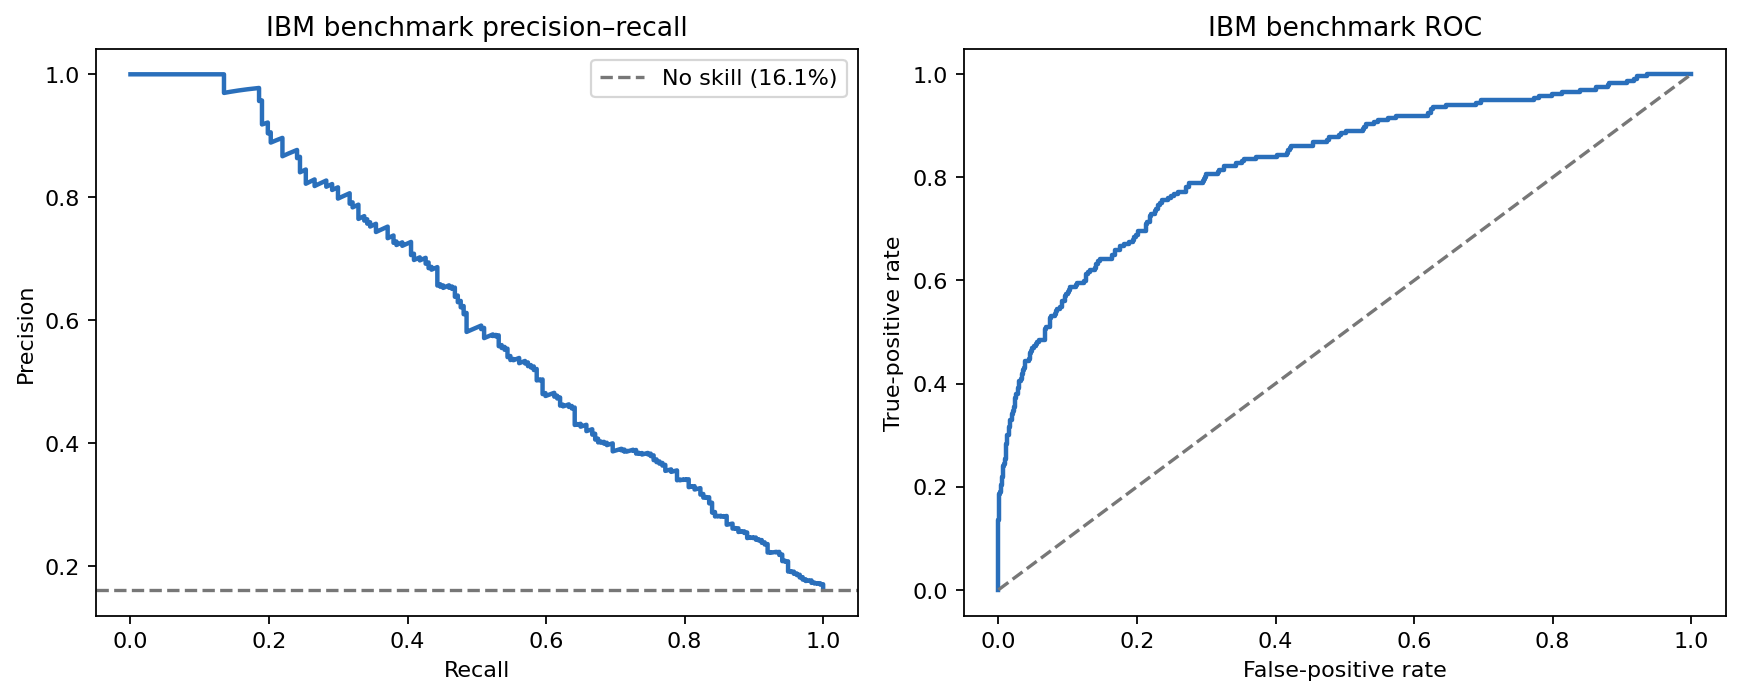

In [4]:
display(
    Image(
        filename=str(
            FIGURE_ROOT / "ibm_benchmark_ranking_curves.png"
        )
    )
)

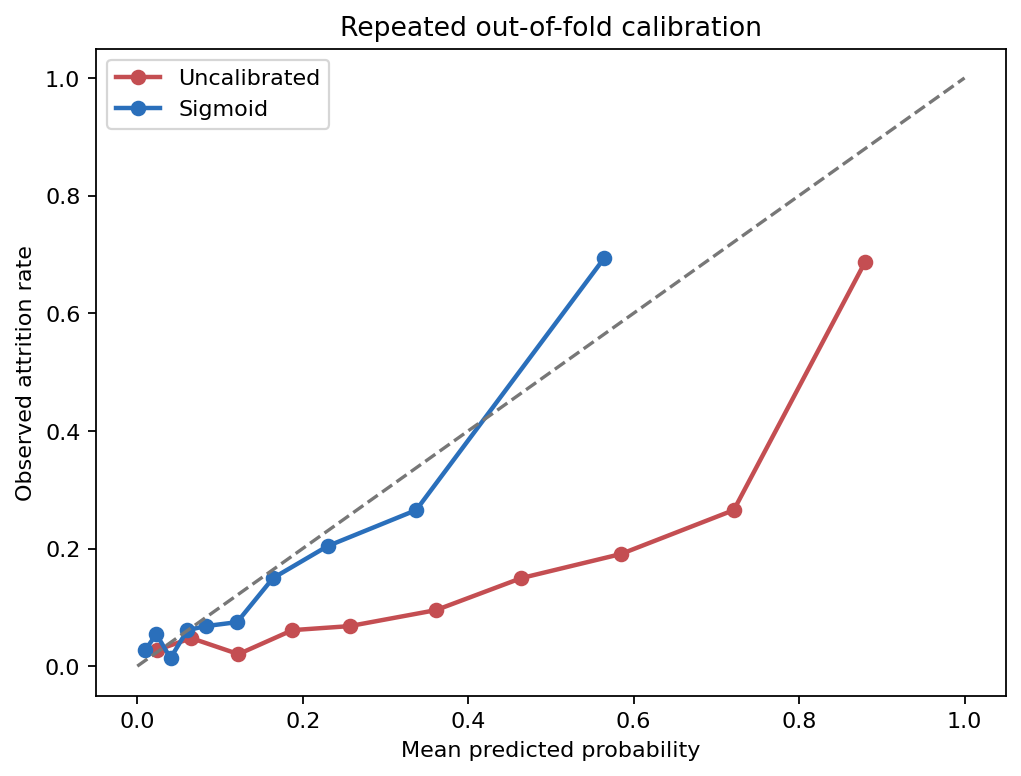

In [5]:
display(
    Image(
        filename=str(
            FIGURE_ROOT / "ibm_benchmark_calibration.png"
        )
    )
)

## 3. Context—not a direct model comparison

The IBM benchmark's PR-AUC, ROC-AUC, and lift are much higher than the primary
model's reserved temporal-test metrics. Every comparison row is marked
**not directly comparable** because the populations, predictors, targets,
sample sizes, synthetic mechanisms, and evaluation designs differ.

In [6]:
context_display = context.copy()
display(context_display)

Metric,Primary Version 2,IBM benchmark,Directly comparable,Boundary
Evaluation design,Once-only 2025 out-of-time final test,Repeated stratified cross-validation,No,"Context only: different synthetic populations, features, targets, and evaluation designs."
Rows,6641,1470,No,"Context only: different synthetic populations, features, targets, and evaluation designs."
Positive rate,0.120916,0.16122448979591836,No,"Context only: different synthetic populations, features, targets, and evaluation designs."
PR-AUC,0.171047,0.6093721951949373,No,"Context only: different synthetic populations, features, targets, and evaluation designs."
ROC-AUC,0.606113,0.8276544122427887,No,"Context only: different synthetic populations, features, targets, and evaluation designs."
Brier score,0.104848,0.09751532681859397,No,"Context only: different synthetic populations, features, targets, and evaluation designs."
Top-decile lift,1.641611,4.30379746835443,No,"Context only: different synthetic populations, features, targets, and evaluation designs."
Target horizon,Explicit next 12 months,Not provided,No,"Context only: different synthetic populations, features, targets, and evaluation designs."


## 4. Stable modeled associations

The table summarizes coefficient direction across 50 outer training fits.
Overtime, frequent travel, and several role or status indicators have stable
modeled associations in this fictional dataset.

These coefficients are conditional associations—not causal effects, policy
recommendations, or evidence about real employees.

In [7]:
stability_display = stability.head(12).copy()
display(stability_display)

Encoded feature,Median coefficient,Lower 95%,Upper 95%,Sign stability,Modeled association
OverTime Yes,1.675,1.422,1.839,100.0%,Higher modeled attrition association
BusinessTravel Travel Frequently,1.400,1.127,1.783,100.0%,Higher modeled attrition association
JobRole Laboratory Technician,1.118,0.798,1.480,100.0%,Higher modeled attrition association
MaritalStatus Single,1.089,0.745,1.381,100.0%,Higher modeled attrition association
JobRole Sales Representative,0.887,0.574,1.341,100.0%,Higher modeled attrition association
JobRole Research Director,-0.840,-1.769,-0.132,98.0%,Lower modeled attrition association
EducationField Life Sciences,-0.789,-1.014,-0.514,100.0%,Lower modeled attrition association
YearsAtCompany,0.693,0.372,0.905,100.0%,Higher modeled attrition association
BusinessTravel Travel Rarely,0.687,0.522,1.051,100.0%,Higher modeled attrition association
EducationField Medical,-0.680,-0.966,-0.382,100.0%,Lower modeled attrition association


## 5. Descriptive subgroup screening

Gender is excluded from model predictors and retained only for aggregate
descriptive screening. Age band and department are also reported. Differences
can remain through correlated predictors and different base rates.

These metrics do not assign a binary fairness verdict.

In [8]:
subgroup_display = subgroups.copy()
display(subgroup_display)

Attribute,Group,Rows,Positive cases,Observed rate,Mean probability,Top-10% selection,Recall,Precision,Brier
Gender,Female,588,87,14.80%,16.91%,10.88%,49.43%,67.19%,0.0907
Gender,Male,882,150,17.01%,15.93%,9.41%,39.33%,71.08%,0.1021
AgeBand,30-39,622,89,14.31%,15.72%,8.68%,44.94%,74.07%,0.0896
AgeBand,40-49,349,34,9.74%,13.17%,6.30%,32.35%,50.00%,0.0751
AgeBand,50+,173,23,13.29%,11.31%,5.20%,17.39%,44.44%,0.1064
AgeBand,Under 30,326,91,27.91%,23.50%,19.02%,51.65%,75.81%,0.1319
Department,Human Resources,63,12,19.05%,19.10%,9.52%,33.33%,66.67%,0.1068
Department,Research & Development,961,133,13.84%,14.18%,7.39%,35.34%,66.20%,0.0901
Department,Sales,446,92,20.63%,20.55%,15.70%,55.43%,72.86%,0.1121


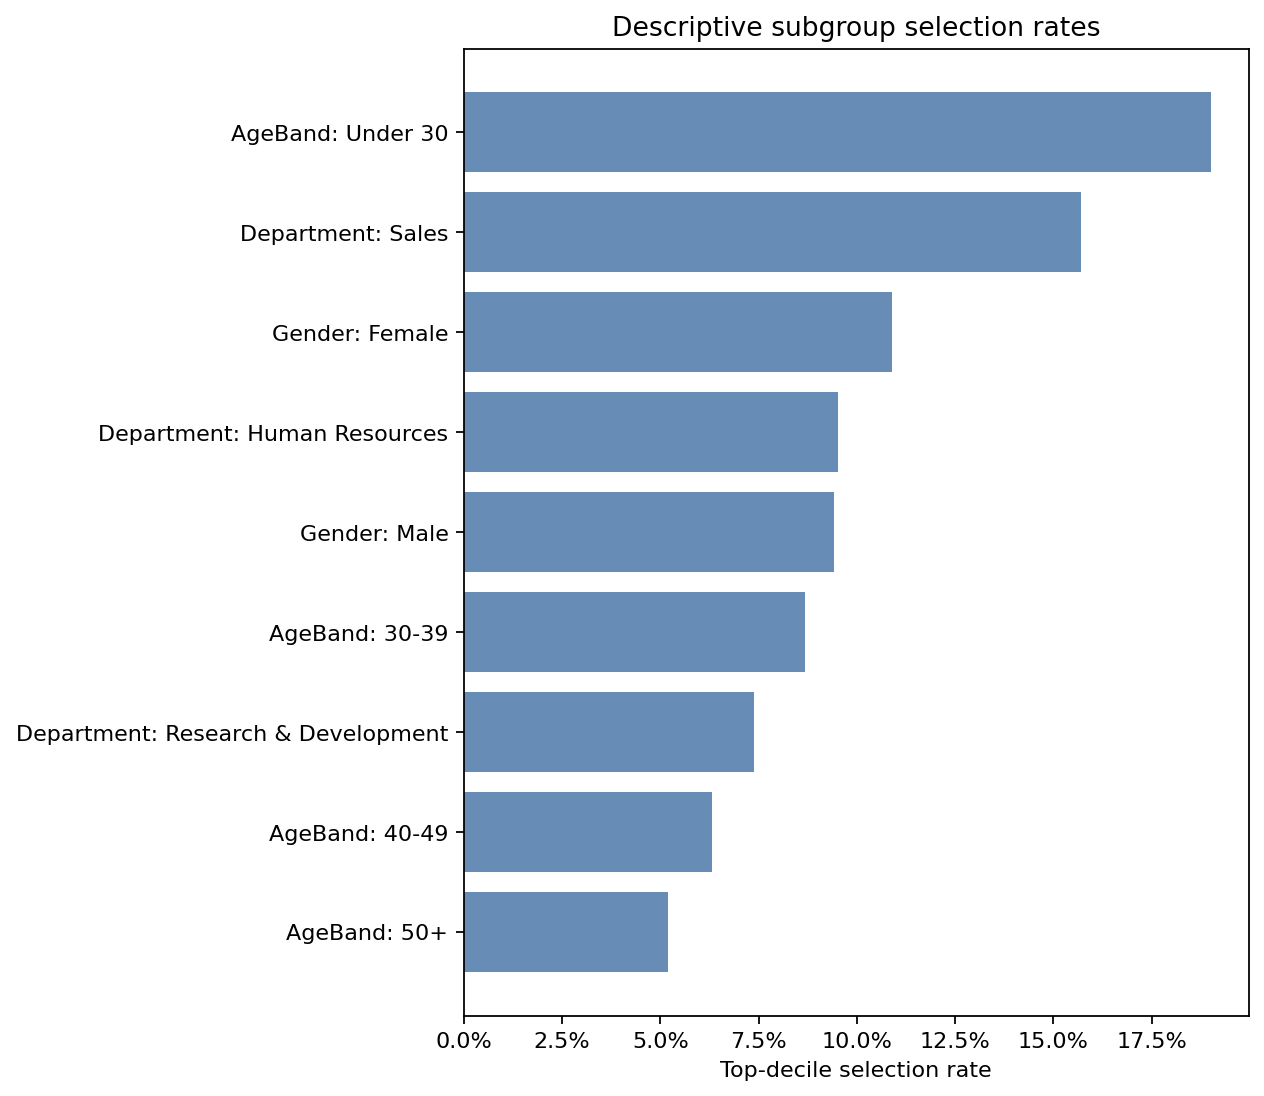

In [9]:
display(
    Image(
        filename=str(
            FIGURE_ROOT / "ibm_benchmark_subgroup_selection.png"
        )
    )
)

## 6. Conceptual feature mapping

The mapping supports discussion of analogous concepts. It is not enough to
combine the datasets or apply one fitted model to the other.

In [10]:
mapping_display = mapping.copy()
display(mapping_display)

IBM field,Primary concept,Limitation
Age,approx_age,Close conceptual match
Education,education_level,Ordinal code versus named categories
Department,department_name,"Same concept, different organizations and categories"
JobLevel,job_level,"Close conceptual match, different scale"
MonthlyIncome,salary_position_percent,Absolute monthly pay versus peer-relative annual pay
PerformanceRating,performance_rating,"Same label, different synthetic generating process"
TrainingTimesLastYear,completed_training_hours_12m,Training count versus completed hours
YearsAtCompany,tenure_years,Close conceptual match
YearsSinceLastPromotion,months_since_promotion,Years versus months; IBM lacks no-prior-promotion flag
Attrition,attrition_next_12m,Static label with unknown horizon versus explicit 12-month target


## 7. Validation and conclusion

All committed source, schema, modeling, calibration, subgroup, and isolation
checks pass. The benchmark demonstrates that the workflow can be reproduced
on a second fictional table. It does not establish real-world external
validity, causal impact, deployment fairness, or transportability.

In [11]:
validation_summary = (
    validation.groupby("status")
    .size()
    .rename("checks")
    .reset_index()
)
display(validation_summary)

Status,Checks
PASS,21


### Reproduce

Run:

```powershell
.\scripts\run_checkpoint53.ps1
```

The source CSV and generated aggregate files remain outside Git. This executed
notebook preserves the reviewer-facing aggregate evidence only.